In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)



In [2]:
features_all = pd.read_pickle("training_features_18042026.pkl")
features_all_temp = features_all
features_all = features_all[~((features_all["Subject"] == "RL03JG") & (features_all["Nap Number"] == 5))] # presentation for this subject is 0 ? somethign weird 

labels = pd.read_pickle("segments.pkl")

print("==========SANITY CHECK==========")
print("Nap IDs align? ", (labels["Nap_ID"].values == features_all["Nap Number"].values).all())
print("Subject rows align? ", (labels["Subject"].values == features_all["Subject"].values).all())
# concatenate dfs
features_all = features_all.reset_index(drop=True)
labels = labels.drop(columns=["Subject"])
labels = labels.reset_index(drop=True)

features_all = pd.concat([features_all, labels], axis=1)  

==========SANITY CHECK==========
Nap IDs align?  True
Subject rows align?  True


In [3]:
subject_plt = "RL09PC"
nap_plt = "01"
subject_df = features_all.loc[(features_all["Subject"] == subject_plt) & (features_all["Nap Number"] == int(nap_plt))] # extract subj info

In [4]:

X_zygo = features_all["Var_Zygo"].to_numpy() #- np.mean(features_all[["Var_Zygo"]])
X_corr = features_all["Var_Corr"].to_numpy() #- np.mean(features_all[["Var_Corr"]] )

y_zygo = features_all["Contraction Zygo"].to_numpy()
y_corr = features_all["Contraction Corr"].to_numpy()

subjects = features_all["Subject"].to_numpy()

all_var_signals = np.concatenate((X_zygo, X_corr), axis=0)
all_label_arrays = np.concatenate((y_zygo, y_corr), axis=0)      
subjects_all = np.concatenate((subjects, subjects), axis=0)  

In [ ]:
plt.plot(Zygo_sig[epoch])
plt.plot(Zygo_var[epoch])
for onset in onsets:
    plt.axvline(x=onset, color='r', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.utils import resample

def extract_features(window):
    d1 = np.diff(window)
    return [
        np.var(window),
        np.mean(np.abs(d1)),
        np.max(window) - np.min(window),
        np.percentile(window, 90),
        np.mean(window),
    ]

def prepare_training_data(var_signals, label_arrays, subject_ids, window=40, stride=1):
    X_all, y_all, groups_all = [], [], []
    half = window // 2

    for subj_id, var, labels in tqdm(zip(subject_ids, var_signals, label_arrays),
                                      total=len(var_signals),
                                      desc="Extracting features"):
        var = np.array(var, dtype=np.float64)
        labels = np.array(labels)

        # all windows at once — shape (n_windows, window_size)
        windows = sliding_window_view(var, window)[::stride]
        y = labels[half: len(var) - half + 1][::stride]

        # vectorized feature extraction
        mean_vals = windows.mean(axis=1)
        var_vals = windows.var(axis=1)
        ranges = windows.max(axis=1) - windows.min(axis=1)
        pct90 = np.percentile(windows, 90, axis=1)
        d1 = np.diff(windows, axis=1)
        mean_abs_d1 = np.abs(d1).mean(axis=1)

        X = np.column_stack([var_vals, mean_abs_d1, ranges, pct90, mean_vals])

        X_all.append(X)
        y_all.append(y)
        groups_all.extend([subj_id] * len(y))

    return np.vstack(X_all), np.concatenate(y_all), np.array(groups_all)



X, y,groups = prepare_training_data(all_var_signals, all_label_arrays,subjects_all)
y = (y > 0).astype(int)

# Build group array — same length as X, each row tagged with its subject
'''
groups = []
for subj_id, var in zip(subjects_all, all_var_signals):
    groups.extend([subj_id] * len(var))
groups = np.array(groups)
 '''
# Split

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.utils import resample

# keep only 10% of samples, stratified by class
X_train_small, y_train_small = resample(
    X_train, y_train, 
    n_samples=len(X_train)//10,
    stratify=y_train,
    random_state=42
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


Extracting features: 100%|██████████| 14280/14280 [00:36<00:00, 390.93it/s]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# keep only 10% of samples, stratified by class
X_train_small, y_train_small = resample(
    X_train, y_train, 
    n_samples=len(X_train)//10,
    stratify=y_train,
    random_state=42
)

# Train
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced',verbose=2)


clf.fit(X_train_small, y_train_small)

from sklearn.metrics import classification_report
print(classification_report(y_test, clf.predict(X_test)))

building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50
building tree 40 of 50


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed: 10.3min


building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50


[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed: 12.8min finished
[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   50.8s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:  1.1min finished


              precision    recall  f1-score   support

           0       0.99      1.00      1.00   6282581
           1       0.99      0.01      0.01     34891

    accuracy                           0.99   6317472
   macro avg       0.99      0.50      0.50   6317472
weighted avg       0.99      0.99      0.99   6317472



In [9]:
np.shape(subjects)

(7140,)

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    6.9s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   16.7s finished


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

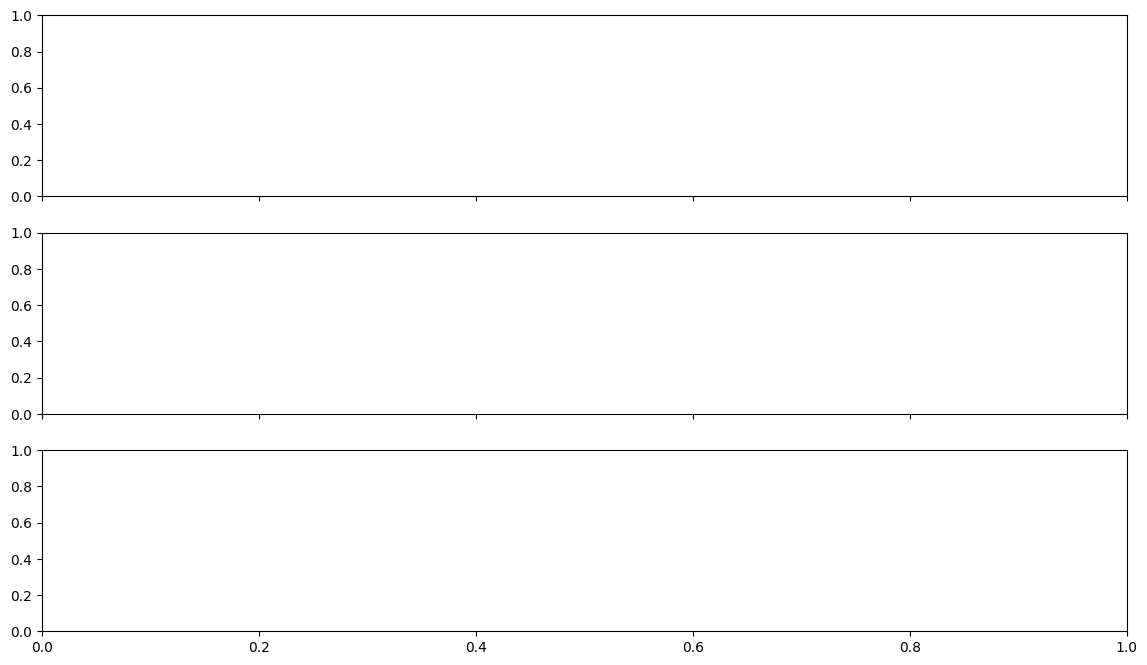

In [14]:
# pick one test subject
# pick one test subject to visualize
idx = 0 
subjects_test = groups[test_idx]
test_subj_id = subjects_test[idx]  # change to a subject you know is in test set
mask = groups[test_idx] == test_subj_id


X_subj = X_test[mask]
y_subj = y_test[mask]

probs = clf.predict_proba(X_subj)[:, 1]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(all_var_signals[test_subj_id], alpha=0.7)
axes[0].set_ylabel('variance')

axes[1].plot(probs, color='red')
axes[1].axhline(0.5, color='gray', linestyle='--')
axes[1].set_ylabel('contraction probability')

axes[2].plot(y_subj, color='green')
axes[2].set_ylabel('ground truth')

plt.tight_layout()
plt.show()

### Old code

In [ ]:
epoch = 20 
smooth_window = 2251 
baseline_pct = 30 
var = Zygo_var[epoch] 

baseline = np.percentile(var, baseline_pct)
norm_var = var / baseline 

smoothed = np.convolve(var, np.ones(smooth_window)/smooth_window, mode='same')
d1 = np.diff(smoothed)
d2 = np.diff(d1)

baseline_accel = np.percentile(np.abs(d2[:len(d2)//4]), 95)
accel_threshold = 10 * baseline_accel  # 5× baseline acceleration
refractory=100

onsets = []
last_onset = -refractory
in_contraction = False

for i in range(len(d2)):
    if not in_contraction and d2[i] > accel_threshold:
        onsets.append(i)
        in_contraction = True
    elif in_contraction and d2[i] < 0:
        # acceleration has reversed — contraction is underway, reset
        in_contraction = False
    
